# Nori — Hands-On Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/main/examples/notebooks/Nori_Demo_Local.ipynb)

**Nori** is a 6M-parameter tabular foundation model for **regression** via in-context learning (ICL). You hand it a few labeled rows as context, and it predicts on new rows in a **single forward pass** — no gradient steps, no hyperparameter search, no per-task training. It was trained *entirely on synthetic data*, so it never saw a real dataset during training.

This notebook walks through everything you need to use Nori in practice:

1. [Install & imports](#install)
2. [Pick a device](#device)
3. [Fit and predict on a real regression task](#regression) — and compare against XGBoost / RandomForest
4. [Cross-validated comparison](#cv)
5. [Probabilistic output](#quantiles) — quantiles and prediction intervals
6. [Interpretability](#interpretability) — Shapley values for a single prediction

Everything runs on a free Colab CPU; a GPU makes it faster but is not required.

<a id="install"></a>
## 1. Install

Running this cell is required. We install Nori plus the optional `eval` and `interpretability` extras used later in the notebook, along with the gradient-boosting baselines we compare against.

On Colab, run the `%pip` line. Locally, prefer **uv** — the commented `uv pip install` / `uv add` lines below do the same thing.

In [ ]:
# Colab / pip:
%pip install -q "synthefy-nori[eval,interpretability]" xgboost scikit-learn

# Local with uv (run in a shell instead of the line above):
#   uv pip install "synthefy-nori[eval,interpretability]" xgboost scikit-learn
# or, inside a uv project:
#   uv add "synthefy-nori[eval,interpretability]" xgboost scikit-learn

> **Colab note:** if the install pulls a new PyTorch/CUDA build, restart the runtime once (**Runtime → Restart runtime**) before continuing so the fresh libraries load cleanly.

## Imports

Running this cell is required.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from synthefy_nori import NoriRegressor

# XGBoost is an optional baseline — the notebook runs fine without it.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed; skipping it as a baseline. "
          "Install with: pip install xgboost")

RANDOM_STATE = 0

<a id="device"></a>
## 2. Pick a device

Nori uses a CUDA GPU automatically when one is visible and falls back to CPU otherwise. This cell just reports what you're running on.

> **Platform note:** macOS, including MacBooks with Apple silicon, is not currently supported. Run this notebook on Colab or a Linux machine.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(torch.cuda.get_device_name(0))

<a id="regression"></a>
## 3. A regression task: California housing

We use the California housing dataset (20,640 rows, 8 numeric features) and predict the median house value for a block. It's a real, noisy regression problem — exactly the kind of thing Nori is built for.

We subsample the training context (ICL conditions on the rows you give it; a few thousand rows is plenty) and hold out a test set for scoring.

In [ ]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ICL conditions on the context rows; a few thousand is enough for a strong fit.
X_ctx = X_train.sample(n=2000, random_state=RANDOM_STATE)
y_ctx = y_train.loc[X_ctx.index]

X_train.head()

### Fit and predict

> **Important:** `nori.fit(X, y)` does **not train or fine-tune Nori**. It only caches the labeled rows as context. The pretrained model weights never change; all model computation happens when `predict` runs its single forward pass.

This differs from RandomForest and XGBoost: their `fit` calls train new task-specific models. We compare them on the same split, with default settings on both sides.

In [ ]:
models = {
    "Nori": NoriRegressor(),  # downloads weights from the HF Hub on first use
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=400, random_state=RANDOM_STATE)

results = {}
for name, model in models.items():
    # For Nori, fit only caches X_ctx/y_ctx; it does not update model weights.
    # The baseline estimators do train task-specific models here.
    model.fit(X_ctx.values, y_ctx.values)
    pred = model.predict(X_test.values)
    results[name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
    }

pd.DataFrame(results).T.sort_values("R2", ascending=False)

<a id="cv"></a>
## 4. Cross-validated comparison

A single split can be lucky. Here we run 5-fold CV on a fixed subsample and plot mean R² with standard-deviation error bars. Nori is evaluated the same way as the baselines — no tuning, no special handling.

In [ ]:
# Fixed subsample keeps CV fast; Nori refits (i.e. re-stores context) per fold.
idx = X.sample(n=3000, random_state=RANDOM_STATE).index
Xs, ys = X.loc[idx].values, y.loc[idx].values
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {
    name: cross_val_score(model, Xs, ys, cv=cv, scoring="r2")
    for name, model in models.items()
}

names = list(cv_scores)
means = [cv_scores[n].mean() for n in names]
stds = [cv_scores[n].std() for n in names]
colors = ["#e0563f" if n == "Nori" else "#7f7f7f" for n in names]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(names, means, yerr=stds, capsize=6, color=colors)
ax.set_ylabel("5-fold CV R²")
ax.set_title("California housing — higher is better")
for i, m in enumerate(means):
    ax.text(i, m + 0.01, f"{m:.3f}", ha="center")
plt.tight_layout()
plt.show()

<a id="quantiles"></a>
## 5. Probabilistic output: quantiles & prediction intervals

Nori's default checkpoint has a 999-quantile head, so you get the **full predictive distribution**, not just a point estimate. Instead of only saying "the house is worth \$250k," Nori can say "there's an 80% chance its value is between \$180k and \$330k."

- `output_type="quantiles"` returns chosen levels — great for prediction intervals.
- `output_type="full"` returns the whole quantile bank — useful for CRPS / interval scoring and calibration.

Quantiles come back in original `y` units and are sorted to a valid (monotone) quantile function per row.

In [ ]:
nori = NoriRegressor().fit(X_ctx.values, y_ctx.values)

# 80% central prediction interval for the first 40 test rows.
q10, q50, q90 = nori.predict(
    X_test.values[:40], output_type="quantiles", quantiles=[0.1, 0.5, 0.9]
)

order = np.argsort(q50)
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x, q10[order], q90[order], alpha=0.25, color="#e0563f",
                label="80% interval")
ax.plot(x, q50[order], color="#e0563f", label="median (q50)")
ax.scatter(x, y_test.values[:40][order], s=18, color="black", zorder=3,
           label="true value")
ax.set_xlabel("test rows (sorted by predicted median)")
ax.set_ylabel("median house value ($100k)")
ax.set_title("Nori predictive intervals")
ax.legend()
plt.tight_layout()
plt.show()

covered = np.mean((y_test.values[:40] >= q10) & (y_test.values[:40] <= q90))
print(f"Empirical coverage of the nominal 80% interval: {covered:.0%}")

<a id="interpretability"></a>
## 6. Interpretability: why did Nori predict that?

`NoriRegressor` is a scikit-learn estimator, so it plugs straight into [shapiq](https://github.com/mmschlk/shapiq) for Shapley values with no adapters. Below we explain a single prediction — which features pushed it up or down — as an additive waterfall.

Explaining prediction for row:
MedInc           4.151800
HouseAge        22.000000
AveRooms         5.663073
AveBedrms        1.075472
Population    1551.000000
AveOccup         4.180593
Latitude        32.580000
Longitude     -117.050000
Name: 14740, dtype: float64


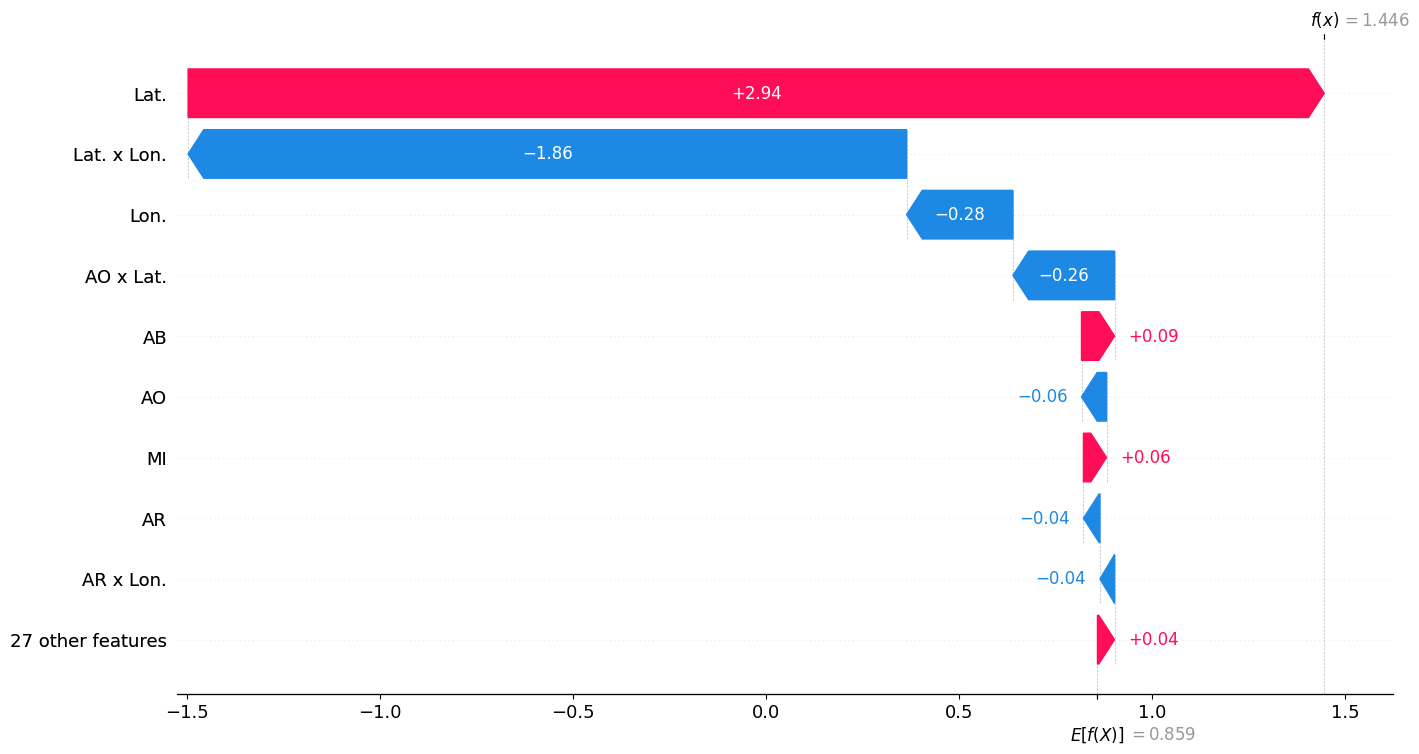

In [ ]:
from synthefy_nori.interpretability.shapiq import get_nori_imputation_explainer

explainer = get_nori_imputation_explainer(nori, X_ctx.values)
sv = explainer.explain(X_test.values[0:1], budget=128)

print("Explaining prediction for row:")
print(X_test.iloc[0])
sv.plot_waterfall(feature_names=list(X.columns))

### How to read the waterfall plot

The plot starts at Nori's **baseline prediction** and shows how each feature moves the prediction for this one row:

- A **positive** contribution pushes the prediction higher than the baseline.
- A **negative** contribution pushes the prediction lower than the baseline. It does **not** mean the feature is bad or should be ignored.
- A longer bar means a larger effect on this prediction; a near-zero bar means little effect for this row.
- The baseline plus all feature contributions equals the final prediction.

These are **local explanations**: the direction and size can change for another row. Consider ignoring a feature only after checking that it is consistently unimportant across representative data—not merely because its contribution is negative here.

## Where to go next

- **One-shot helper:** skip the object entirely with `from synthefy_nori import predict; predict(X_train, y_train, X_test, task="regression")`.
- **Your own checkpoint:** `NoriRegressor(model_path="path/to/checkpoint.pt")`.
- **More interpretability:** partial-dependence plots and sequential feature selection live in `synthefy_nori.interpretability` — see [`examples/interpretability_regression.py`](../interpretability_regression.py).
- **Docs & benchmarks:** [docs.synthefy.com/nori](https://docs.synthefy.com/nori/) and the [model card on Hugging Face](https://huggingface.co/Synthefy/Nori).

Questions? Join the [Discord](https://discord.gg/rTCCJkht4).